<a href="https://colab.research.google.com/github/agief-G1A024037/Kelompok-07-09-015-037-041-/blob/main/Bagian2No2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulasi KNN dengan Dataset Kucing Anjing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


In [2]:
np.random.seed(42)

cats_size   = np.random.normal(3.5, 0.8, 30)
cats_energy = np.random.normal(5.0, 1.2, 30)
cats_label  = np.zeros(30, dtype=int)

dogs_size   = np.random.normal(7.0, 1.5, 30)
dogs_energy = np.random.normal(7.5, 1.0, 30)
dogs_label  = np.ones(30, dtype=int)

unusual_size   = np.array([2.5])
unusual_energy = np.array([4.5])
unusual_label  = np.array([1])

X = np.column_stack([
    np.concatenate([cats_size, dogs_size, unusual_size]),
    np.concatenate([cats_energy, dogs_energy, unusual_energy])
])
y = np.concatenate([cats_label, dogs_label, unusual_label])
X = np.clip(X, 1, 10)

label_names  = {0: 'Kucing', 1: 'Anjing'}
unusual_flag = ['Ya' if i == len(y)-1 else 'Tidak' for i in range(len(y))]

print('Dataset dibuat:', len(y), 'sampel')

Dataset dibuat: 61 sampel


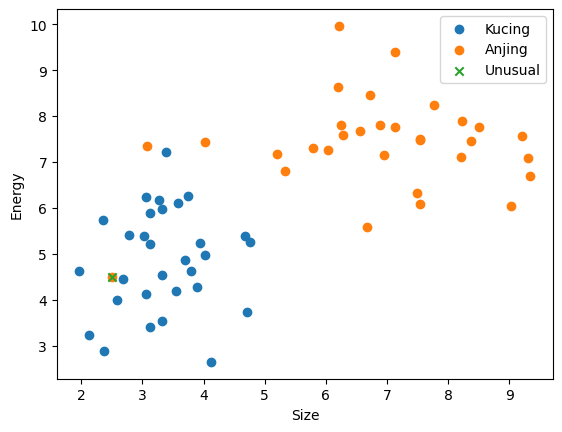

In [3]:
plt.scatter(X[y==0][:,0], X[y==0][:,1], label='Kucing')
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='Anjing')
plt.scatter(X[-1,0], X[-1,1], label='Unusual', marker='x')
plt.xlabel('Size')
plt.ylabel('Energy')
plt.legend()
plt.show()

In [4]:
test = np.array([[3,5]])
for k in [1,3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X,y)
    print(f'K={k} ->', knn.predict(test))

K=1 -> [0]
K=3 -> [0]
K=5 -> [0]
K=7 -> [0]


# Apa yang terjadi apa yang akan terjadi jika nilai K diatur terlalu kecil (misal K=1) ketika menemui data yang "aneh" (unusual training tokens).

Jika nilai K diatur terlalu kecil (misalnya K=1), maka algoritma KNN hanya
mengandalkan satu tetangga terdekat dalam menentukan kelas suatu data.

Ketika terdapat data yang "aneh" (unusual training token atau outlier),
maka data tersebut dapat menjadi tetangga terdekat dari data uji.
Akibatnya, model akan mengikuti label dari data aneh tersebut,
meskipun label tersebut tidak mewakili pola mayoritas.

Hal ini menyebabkan terjadinya kesalahan klasifikasi (misclassification),
karena model terlalu sensitif terhadap noise atau outlier dalam data.

Kondisi ini juga disebut sebagai overfitting, dimana model terlalu
mengikuti data training secara spesifik dan tidak mampu melakukan
generalisasi dengan baik pada data baru.